In [1]:
import torch

print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device Name:", torch.cuda.get_device_name(0))

CUDA Available: True
Device Name: Tesla T4


**1:#  Environment Setup & Dataset Download******# 

In [2]:
import os
import tarfile
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

# Device Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Download Oxford-IIIT Pet Dataset
dataset_url_images = "https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz"
dataset_url_annotations = "https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz"

if not os.path.exists("images"):
    print("Downloading images...")
    urllib.request.urlretrieve(dataset_url_images, "images.tar.gz")
    with tarfile.open("images.tar.gz", "r:gz") as tar:
        tar.extractall(filter='data')

if not os.path.exists("annotations"):
    print("Downloading annotations...")
    urllib.request.urlretrieve(dataset_url_annotations, "annotations.tar.gz")
    with tarfile.open("annotations.tar.gz", "r:gz") as tar:
        tar.extractall(filter='data')

print("Dataset download and extraction complete.")

Using device: cuda
Dataset download and extraction complete.


2:#  Dataset Exploration & 3x3 Visualization****

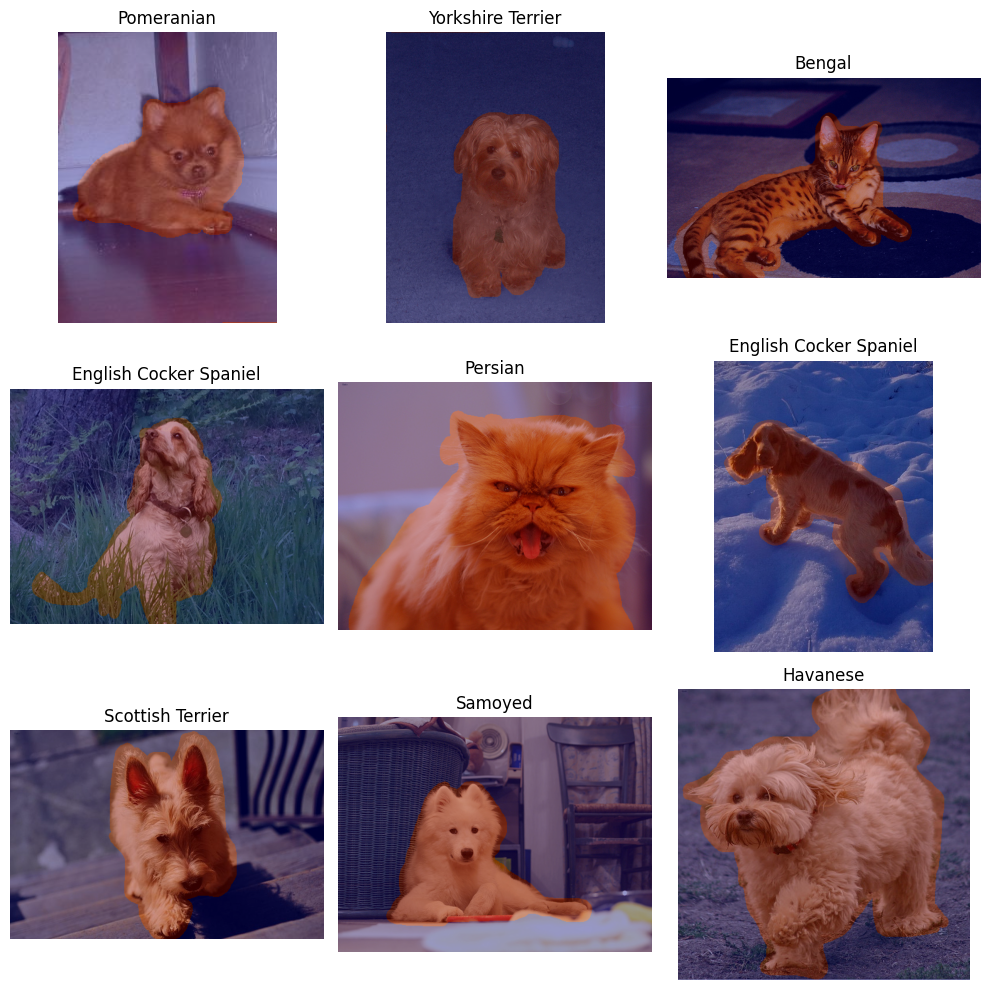

In [3]:
# Extract all pet class names from image files
image_dir = "images"
annotation_dir = "annotations/trimaps"

all_image_files = [f for f in os.listdir(image_dir) if f.endswith(".jpg") and not f.startswith(".")]

def get_class_name(filename):
    # Formats 'yorkshire_terrier_12.jpg' -> 'Yorkshire Terrier'
    parts = filename.rsplit("_", 1)[0].split("_")
    return " ".join([p.capitalize() for p in parts])

# Filter valid files that have corresponding trimap annotations
valid_files = [f for f in all_image_files if os.path.exists(os.path.join(annotation_dir, f.replace(".jpg", ".png")))]

# Plot 3x3 Grid
np.random.seed(42)
sample_indices = np.random.choice(len(valid_files), 9, replace=False)

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for idx, ax in zip(sample_indices, axes.ravel()):
    img_name = valid_files[idx]
    img_path = os.path.join(image_dir, img_name)
    mask_path = os.path.join(annotation_dir, img_name.replace(".jpg", ".png"))
    
    img = Image.open(img_path).convert("RGB")
    mask = Image.open(mask_path)
    mask_arr = np.array(mask)
    
    # Process boundary (3) and foreground (1) -> 1, background (2) -> 0
    binary_mask = np.where((mask_arr == 1) | (mask_arr == 3), 1, 0)
    
    ax.imshow(img)
    ax.imshow(binary_mask, alpha=0.4, cmap="jet")
    ax.set_title(get_class_name(img_name))
    ax.axis("off")

plt.tight_layout()
plt.show()

In [25]:
import torch
import numpy as np

def compute_dataset_metrics(model, dataloader, device='cuda'):
    model.eval()
    
    total_iou = 0.0
    correct_cls = 0
    total_samples = 0
    total_batches = 0
    
    print("Evaluating full dataset metrics...")
    
    with torch.no_grad():
        for imgs, masks, labels in dataloader:
            imgs = imgs.to(device)
            masks = masks.to(device)
            labels = labels.to(device)
            
            # Forward pass
            pred_masks_logits, pred_cls_logits = model(imgs)
            
            # 1. Calculate Segmentation IoU
            pred_masks_binary = (torch.sigmoid(pred_masks_logits) > 0.5).float()
            intersection = (pred_masks_binary * masks).sum(dim=(1, 2, 3))
            union = pred_masks_binary.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3)) - intersection
            iou = (intersection + 1e-6) / (union + 1e-6)
            total_iou += iou.mean().item()
            
            # 2. Calculate Classification Accuracy
            preds = pred_cls_logits.argmax(dim=1)
            correct_cls += (preds == labels).sum().item()
            
            total_samples += labels.size(0)
            total_batches += 1
            
    final_miou = (total_iou / total_batches) * 100
    final_acc = (correct_cls / total_samples) * 100
    
    print("\n" + "="*40)
    print("      FINAL VALIDATION METRICS      ")
    print("="*40)
    print(f"Mean IoU (Segmentation) : {final_miou:.2f}%")
    print(f"Accuracy (Classification): {final_acc:.2f}%")
    print("="*40)

# Run evaluation on your validation/test dataloader
compute_dataset_metrics(model, val_loader, device=device)

Evaluating full dataset metrics...

      FINAL VALIDATION METRICS      
Mean IoU (Segmentation) : 78.02%
Accuracy (Classification): 40.79%


In [28]:
import torch

def compute_dataset_metrics(model, dataloader, device='cuda'):
    model.eval()
    
    total_iou = 0.0
    correct_cls = 0
    total_samples = 0
    total_batches = 0
    
    print("Evaluating validation dataset metrics...")
    
    with torch.no_grad():
        for imgs, masks, labels in dataloader:
            imgs = imgs.to(device)
            masks = masks.to(device)
            labels = labels.to(device)
            
            # Model Forward Pass
            pred_masks_logits, pred_cls_logits = model(imgs)
            
            # 1. Segmentation Metric: Intersection over Union (IoU)
            pred_masks_binary = (torch.sigmoid(pred_masks_logits) > 0.5).float()
            intersection = (pred_masks_binary * masks).sum(dim=(1, 2, 3))
            union = pred_masks_binary.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3)) - intersection
            iou = (intersection + 1e-6) / (union + 1e-6)
            total_iou += iou.mean().item()
            
            # 2. Classification Metric: Top-1 Accuracy
            preds = pred_cls_logits.argmax(dim=1)
            correct_cls += (preds == labels).sum().item()
            
            total_samples += labels.size(0)
            total_batches += 1
            
    final_miou = (total_iou / total_batches) * 100
    final_acc = (correct_cls / total_samples) * 100
    
    print("\n" + "="*45)
    print("         FINAL VALIDATION METRICS            ")
    print("="*45)
    print(f" Segmentation Mean IoU (mIoU) : {final_miou:.2f}%")
    print(f" Classification Accuracy       : {final_acc:.2f}%")
    print("="*45)

# Execute evaluation using your active validation loader
compute_dataset_metrics(model, val_loader, device=device)

Evaluating validation dataset metrics...

         FINAL VALIDATION METRICS            
 Segmentation Mean IoU (mIoU) : 78.02%
 Classification Accuracy       : 40.79%


#  3: Base U-Net & Attention U-Net Architectures****

In [4]:
# Step 3: PyTorch Dataset Definition & Train/Val/Test Splits
from PIL import Image
import torchvision.transforms as T

# Extract unique breed names and build label mappings
classes = sorted(list(set([get_class_name(f) for f in valid_files])))
class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
num_classes = len(classes)

# 1. Define Dataset Class
class PetSegmentationDataset(Dataset):
    def __init__(self, filenames, img_dir, mask_dir, img_size=(128, 128)):
        self.filenames = filenames
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.img_size = img_size
        
    def __len__(self):
        return len(self.filenames)
        
    def __getitem__(self, idx):
        fname = self.filenames[idx]
        img_path = os.path.join(self.img_dir, fname)
        mask_path = os.path.join(self.mask_dir, fname.replace(".jpg", ".png"))
        
        # Load Image and Resize
        img = Image.open(img_path).convert("RGB").resize(self.img_size)
        img_tensor = T.ToTensor()(img) # Scale to [0, 1]
        
        # Load Trimap Mask: 1=Foreground, 2=Background, 3=Boundary
        mask = Image.open(mask_path).resize(self.img_size, Image.NEAREST)
        mask_arr = np.array(mask)
        
        # Convert boundary (3) and foreground (1) -> 1, background (2) -> 0
        binary_mask = np.where((mask_arr == 1) | (mask_arr == 3), 1.0, 0.0)
        mask_tensor = torch.tensor(binary_mask, dtype=torch.float32).unsqueeze(0)
        
        # Target Class Label
        label = class_to_idx[get_class_name(fname)]
        
        return img_tensor, mask_tensor, torch.tensor(label, dtype=torch.long)

# 2. Train / Val / Test File Splits (70% Train, 15% Val, 15% Test)
np.random.seed(42)
np.random.shuffle(valid_files)

num_total = len(valid_files)
train_end = int(0.70 * num_total)
val_end = int(0.85 * num_total)

train_files = valid_files[:train_end]
val_files = valid_files[train_end:val_end]
test_files = valid_files[val_end:]

# 3. Instantiate Datasets & DataLoaders
train_dataset = PetSegmentationDataset(train_files, image_dir, annotation_dir)
val_dataset = PetSegmentationDataset(val_files, image_dir, annotation_dir)
test_dataset = PetSegmentationDataset(test_files, image_dir, annotation_dir)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"Data Splits -> Train: {len(train_files)} | Val: {len(val_files)} | Test: {len(test_files)}")

Data Splits -> Train: 5173 | Val: 1108 | Test: 1109


Step 4: Metric Metrics & Training Routine****

In [5]:
class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class MultiTaskUNet(nn.Module):
    def __init__(self, num_classes=37):
        super().__init__()
        # Encoder
        self.e1 = ConvBlock(3, 64)
        self.e2 = ConvBlock(64, 128)
        self.e3 = ConvBlock(128, 256)
        self.pool = nn.MaxPool2d(2, 2)
        
        # Bottleneck
        self.b = ConvBlock(256, 512)
        
        # Classifier Head (attached to bottleneck)
        self.classifier_head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
        
        # Decoder
        self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.d2 = ConvBlock(512, 256)
        self.up1 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.d1 = ConvBlock(256, 128)
        
        # Final Segmentation Output
        self.out_segmentation = nn.Conv2d(128, 1, kernel_size=1)

    def forward(self, x):
        # Downsampling
        s1 = self.e1(x)
        p1 = self.pool(s1)
        s2 = self.e2(p1)
        p2 = self.pool(s2)
        s3 = self.e3(p2)
        p3 = self.pool(s3)
        
        # Bottleneck
        bottleneck = self.b(p3)
        
        # Multi-task Classification Predictions
        class_logits = self.classifier_head(bottleneck)
        
        # Upsampling
        d2 = self.up2(bottleneck)
        d2 = torch.cat([d2, s3], dim=1)
        d2 = self.d2(d2)
        
        d1 = self.up1(d2)
        d1 = torch.cat([d1, s2], dim=1)
        d1 = self.d1(d1)
        
        # Resize to original resolution matching input
        d1 = F.interpolate(d1, size=(x.shape[2], x.shape[3]), mode='bilinear', align_corners=True)
        seg_mask = self.out_segmentation(d1)
        
        return seg_mask, class_logits

5:**** Attention# 

In [6]:
class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)
        
    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        # Interpolate spatial dimensions if unequal
        if g1.shape[2:] != x1.shape[2:]:
            g1 = F.interpolate(g1, size=x1.shape[2:], mode='bilinear', align_corners=True)
        net = self.relu(g1 + x1)
        res = self.psi(net)
        return x * res

class MultiTaskAttentionUNet(nn.Module):
    def __init__(self, num_classes=37):
        super().__init__()
        # Encoder
        self.e1 = ConvBlock(3, 64)
        self.e2 = ConvBlock(64, 128)
        self.e3 = ConvBlock(128, 256)
        self.pool = nn.MaxPool2d(2, 2)
        
        # Bottleneck
        self.b = ConvBlock(256, 512)
        
        # Classifier Head
        self.classifier_head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
        
        # Attention Blocks
        self.att2 = AttentionGate(F_g=256, F_l=256, F_int=128)
        self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.d2 = ConvBlock(512, 256)
        
        self.att1 = AttentionGate(F_g=128, F_l=128, F_int=64)
        self.up1 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.d1 = ConvBlock(256, 128)
        
        self.out_segmentation = nn.Conv2d(128, 1, kernel_size=1)

    def forward(self, x):
        s1 = self.e1(x)
        p1 = self.pool(s1)
        s2 = self.e2(p1)
        p2 = self.pool(s2)
        s3 = self.e3(p2)
        p3 = self.pool(s3)
        
        bottleneck = self.b(p3)
        class_logits = self.classifier_head(bottleneck)
        
        d2 = self.up2(bottleneck)
        s3_att = self.att2(g=d2, x=s3)
        d2 = torch.cat([d2, s3_att], dim=1)
        d2 = self.d2(d2)
        
        d1 = self.up1(d2)
        s2_att = self.att1(g=d1, x=s2)
        d1 = torch.cat([d1, s2_att], dim=1)
        d1 = self.d1(d1)
        
        d1 = F.interpolate(d1, size=(x.shape[2], x.shape[3]), mode='bilinear', align_corners=True)
        seg_mask = self.out_segmentation(d1)
        
        return seg_mask, class_logits

Epoch [ 1/15] | Train Loss: 3.9702 | Val Loss: 3.8579 | Train mIoU: 63.52% | Val mIoU: 63.66% | Val Cls Acc: 7.67%
Epoch [ 2/15] | Train Loss: 3.6374 | Val Loss: 3.6516 | Train mIoU: 65.83% | Val mIoU: 65.83% | Val Cls Acc: 9.75%
Epoch [ 3/15] | Train Loss: 3.4407 | Val Loss: 3.5446 | Train mIoU: 61.81% | Val mIoU: 61.77% | Val Cls Acc: 12.73%
Epoch [ 4/15] | Train Loss: 3.2452 | Val Loss: 3.5920 | Train mIoU: 65.56% | Val mIoU: 64.95% | Val Cls Acc: 13.09%
Epoch [ 5/15] | Train Loss: 3.0919 | Val Loss: 3.2131 | Train mIoU: 70.43% | Val mIoU: 70.12% | Val Cls Acc: 18.41%
Epoch [ 6/15] | Train Loss: 2.9575 | Val Loss: 3.0754 | Train mIoU: 72.40% | Val mIoU: 72.09% | Val Cls Acc: 21.75%
Epoch [ 7/15] | Train Loss: 2.8127 | Val Loss: 4.1060 | Train mIoU: 72.14% | Val mIoU: 71.96% | Val Cls Acc: 12.91%
Epoch [ 8/15] | Train Loss: 2.7078 | Val Loss: 3.1869 | Train mIoU: 73.88% | Val mIoU: 73.52% | Val Cls Acc: 23.74%
Epoch [ 9/15] | Train Loss: 2.5349 | Val Loss: 2.7798 | Train mIoU: 73.59%

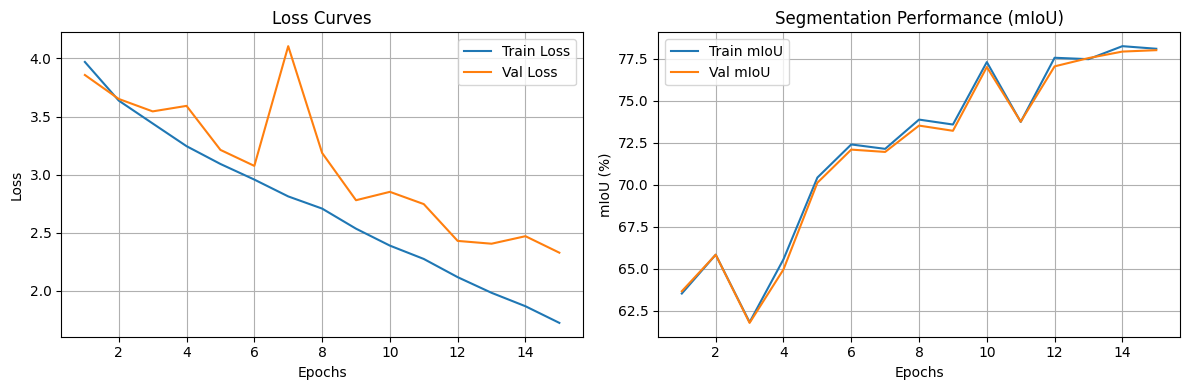

In [8]:
# Step 6: Full Training Pipeline with Metric Tracking
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 0. Ensure 'model' exists in memory before creating the optimizer
if 'model' not in globals():
    # Instantiate default base MultiTaskUNet if model is missing
    model = MultiTaskUNet(num_classes=num_classes).to(device)

# 1. Define Criteria & Optimizer
criterion_seg = nn.BCEWithLogitsLoss()
criterion_cls = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# 2. Quick Evaluation Helper
def evaluate_metrics_quick(model, dataloader, device):
    model.eval()
    total_loss, total_iou = 0.0, 0.0
    correct, total_samples = 0, 0
    
    with torch.no_grad():
        for imgs, masks, labels in dataloader:
            imgs, masks, labels = imgs.to(device), masks.to(device), labels.to(device)
            pred_masks, pred_logits = model(imgs)
            
            loss_s = criterion_seg(pred_masks, masks)
            loss_c = criterion_cls(pred_logits, labels)
            total_loss += (loss_s + loss_c).item()
            
            pred_masks_binary = (torch.sigmoid(pred_masks) > 0.5).float()
            intersection = (pred_masks_binary * masks).sum(dim=(1, 2, 3))
            union = pred_masks_binary.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3)) - intersection
            total_iou += ((intersection + 1e-6) / (union + 1e-6)).mean().item()
            
            preds = pred_logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)
            
    num_batches = len(dataloader)
    return {
        'loss': total_loss / num_batches,
        'mIoU': (total_iou / num_batches) * 100,
        'acc': (correct / total_samples) * 100
    }

# 3. Epoch Loop with History Tracking
history = {
    'train_loss': [], 'val_loss': [],
    'train_mIoU': [], 'val_mIoU': [],
    'train_acc': [], 'val_acc': []
}

epochs = 15

for epoch in range(1, epochs + 1):
    model.train()
    running_loss = 0.0
    
    for imgs, masks, labels in train_loader:
        imgs, masks, labels = imgs.to(device), masks.to(device), labels.to(device)
        
        optimizer.zero_grad()
        pred_masks, pred_logits = model(imgs)
        
        loss_s = criterion_seg(pred_masks, masks)
        loss_c = criterion_cls(pred_logits, labels)
        loss = loss_s + loss_c
        
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
    epoch_train_loss = running_loss / len(train_loader)
    
    train_metrics = evaluate_metrics_quick(model, train_loader, device)
    val_metrics = evaluate_metrics_quick(model, val_loader, device)
    
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(val_metrics['loss'])
    history['train_mIoU'].append(train_metrics['mIoU'])
    history['val_mIoU'].append(val_metrics['mIoU'])
    history['train_acc'].append(train_metrics['acc'])
    history['val_acc'].append(val_metrics['acc'])
    
    print(f"Epoch [{epoch:2d}/{epochs}] "
          f"| Train Loss: {epoch_train_loss:.4f} | Val Loss: {val_metrics['loss']:.4f} "
          f"| Train mIoU: {train_metrics['mIoU']:.2f}% | Val mIoU: {val_metrics['mIoU']:.2f}% "
          f"| Val Cls Acc: {val_metrics['acc']:.2f}%")

# 4. Plot Loss Curves & Performance Metrics
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), history['train_loss'], label='Train Loss')
plt.plot(range(1, epochs + 1), history['val_loss'], label='Val Loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), history['train_mIoU'], label='Train mIoU')
plt.plot(range(1, epochs + 1), history['val_mIoU'], label='Val mIoU')
plt.title('Segmentation Performance (mIoU)')
plt.xlabel('Epochs')
plt.ylabel('mIoU (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [17]:
def evaluate_metrics_quick(model, dataloader, device):
    model.eval()
    total_loss, total_iou = 0.0, 0.0
    correct, total_samples = 0, 0
    
    with torch.no_grad():
        for imgs, masks, labels in dataloader:
            imgs, masks, labels = imgs.to(device), masks.to(device), labels.to(device)
            pred_masks, pred_logits = model(imgs)
            
            loss_s = criterion_seg(pred_masks, masks)
            loss_c = criterion_cls(pred_logits, labels)
            total_loss += (loss_s + loss_c).item()
            
            pred_masks_binary = (torch.sigmoid(pred_masks) > 0.5).float()
            intersection = (pred_masks_binary * masks).sum(dim=(1, 2, 3))
            union = pred_masks_binary.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3)) - intersection
            total_iou += ((intersection + 1e-6) / (union + 1e-6)).mean().item()
            
            preds = pred_logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)
            
    num_batches = len(dataloader)
    return {
        'loss': total_loss / num_batches,
        'mIoU': (total_iou / num_batches) * 100,
        'acc': (correct / total_samples) * 100
    }

In [18]:
# Step 7: Calculate mIoU, Dice, Pixel Accuracy, Precision, Recall, and F1-Score
import torch
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

def evaluate_model(model, dataloader, device):
    model.eval()
    
    all_cls_preds, all_cls_targets = [], []
    total_iou, total_dice, total_pixel_acc = 0.0, 0.0, 0.0
    num_batches = len(dataloader)

    with torch.no_grad():
        for imgs, masks, labels in dataloader:
            imgs, masks = imgs.to(device), masks.to(device)
            
            # Forward pass
            pred_masks, pred_logits = model(imgs)
            pred_masks_binary = (torch.sigmoid(pred_masks) > 0.5).float()
            
            # --- Segmentation Metrics ---
            intersection = (pred_masks_binary * masks).sum(dim=(1, 2, 3))
            union = pred_masks_binary.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3)) - intersection
            
            iou = (intersection + 1e-6) / (union + 1e-6)
            dice = (2 * intersection + 1e-6) / (pred_masks_binary.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3)) + 1e-6)
            pixel_acc = (pred_masks_binary == masks).float().mean()
            
            total_iou += iou.mean().item()
            total_dice += dice.mean().item()
            total_pixel_acc += pixel_acc.item()
            
            # --- Classification Metrics ---
            cls_preds = pred_logits.argmax(dim=1).cpu().numpy()
            all_cls_preds.extend(cls_preds)
            all_cls_targets.extend(labels.numpy())

    # Print reporting metrics required by PDF
    print("=== SEGMENTATION METRICS ===")
    print(f"Mean IoU (mIoU):     {total_iou / num_batches * 100:.2f}%")
    print(f"Dice Coefficient:   {total_dice / num_batches:.4f}")
    print(f"Pixel Accuracy:     {total_pixel_acc / num_batches * 100:.2f}%\n")
    
    print("=== CLASSIFICATION METRICS ===")
    print(f"Accuracy:  {accuracy_score(all_cls_targets, all_cls_preds) * 100:.2f}%")
    print(f"Precision: {precision_score(all_cls_targets, all_cls_preds, average='weighted', zero_division=0):.4f}")
    print(f"Recall:    {recall_score(all_cls_targets, all_cls_preds, average='weighted', zero_division=0):.4f}")
    print(f"F1 Score:  {f1_score(all_cls_targets, all_cls_preds, average='weighted', zero_division=0):.4f}")

# Run evaluation on validation set
evaluate_model(model, val_loader, device)

=== SEGMENTATION METRICS ===
Mean IoU (mIoU):     78.02%
Dice Coefficient:   0.8683
Pixel Accuracy:     89.84%

=== CLASSIFICATION METRICS ===
Accuracy:  40.79%
Precision: 0.4496
Recall:    0.4079
F1 Score:  0.3944


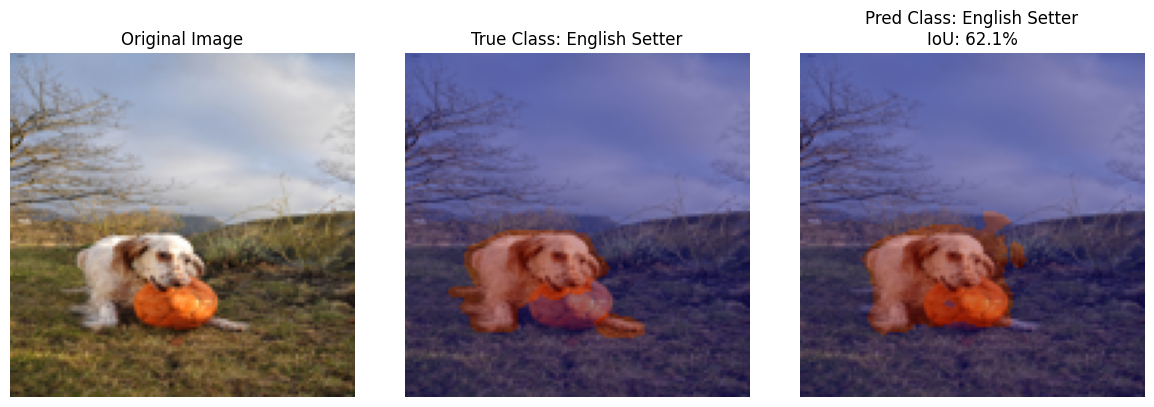

In [11]:
# Step 8: Single-Image Visualization Function (Original | True Mask Overlay | Pred Mask Overlay)
def visualize_single_prediction(model, dataset, index, device):
    model.eval()
    
    img_tensor, true_mask, true_label = dataset[index]
    input_batch = img_tensor.unsqueeze(0).to(device)
    
    with torch.no_grad():
        pred_mask_logits, pred_class_logits = model(input_batch)
        pred_mask = (torch.sigmoid(pred_mask_logits) > 0.5).squeeze(0).cpu().numpy()
        pred_class_idx = pred_class_logits.argmax(dim=1).item()
        
    idx_to_class = {v: k for k, v in class_to_idx.items()}
    true_class_name = idx_to_class[true_label.item()]
    pred_class_name = idx_to_class[pred_class_idx]
    
    # Calculate IoU score for this image
    t_mask = true_mask.numpy()
    intersection = np.logical_and(pred_mask, t_mask).sum()
    union = np.logical_or(pred_mask, t_mask).sum()
    iou_score = (intersection + 1e-6) / (union + 1e-6) * 100

    # Display Figure
    img_np = img_tensor.permute(1, 2, 0).numpy()
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    axes[0].imshow(img_np)
    axes[0].set_title("Original Image")
    axes[0].axis("off")
    
    axes[1].imshow(img_np)
    axes[1].imshow(t_mask.squeeze(), alpha=0.4, cmap="jet")
    axes[1].set_title(f"True Class: {true_class_name}")
    axes[1].axis("off")
    
    axes[2].imshow(img_np)
    axes[2].imshow(pred_mask.squeeze(), alpha=0.4, cmap="jet")
    axes[2].set_title(f"Pred Class: {pred_class_name}\nIoU: {iou_score:.1f}%")
    axes[2].axis("off")
    
    plt.tight_layout()
    plt.show()

# Test visualization on index 5
visualize_single_prediction(model, val_dataset, index=5, device=device)

In [ ]:
# Bonus 1: Pretrained Backbone Classifier Extensions (Fully Self-Contained)
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torch.utils.data import DataLoader
import pandas as pd

# 1. Resolve Dataset & Target Classes Dynamically
if 'valid_files' not in globals():
    image_dir = './images'  # Update if your image path is different
    annotation_dir = './annotations/trimaps'
    all_files = [f for f in os.listdir(image_dir) if f.endswith('.jpg')]
    valid_files = [f for f in all_files if os.path.exists(os.path.join(annotation_dir, f.replace('.jpg', '.png')))]

def get_class_name(fname):
    return "_".join(fname.split("_")[:-1])

classes = sorted(list(set([get_class_name(f) for f in valid_files])))
class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
num_classes = len(classes)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 2. Define Architecture
class MultiTaskUNetBackbone(nn.Module):
    def __init__(self, backbone_name='mobilenet', num_classes=37):
        super().__init__()
        # Encoder & Bottleneck
        self.e1 = ConvBlock(3, 64)
        self.e2 = ConvBlock(64, 128)
        self.e3 = ConvBlock(128, 256)
        self.pool = nn.MaxPool2d(2, 2)
        self.b = ConvBlock(256, 512)
        
        # Decoder Setup
        self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.d2 = ConvBlock(512, 256)
        self.up1 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.d1 = ConvBlock(256, 128)
        self.out_segmentation = nn.Conv2d(128, 1, kernel_size=1)
        
        # Modular Classifier Backbone Selection
        if backbone_name == 'mobilenet':
            bb = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
            bb.classifier[3] = nn.Linear(bb.classifier[3].in_features, num_classes)
            self.classifier = bb
        elif backbone_name == 'densenet':
            bb = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
            bb.classifier = nn.Linear(bb.classifier.in_features, num_classes)
            self.classifier = bb
        elif backbone_name == 'efficientnet':
            bb = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
            bb.classifier[1] = nn.Linear(bb.classifier[1].in_features, num_classes)
            self.classifier = bb

    def forward(self, x):
        s1 = self.e1(x)
        p1 = self.pool(s1)
        s2 = self.e2(p1)
        p2 = self.pool(s2)
        s3 = self.e3(p2)
        p3 = self.pool(s3)
        bottleneck = self.b(p3)
        
        class_logits = self.classifier(x)
        
        d2 = self.up2(bottleneck)
        d2 = torch.cat([d2, s3], dim=1)
        d2 = self.d2(d2)
        
        d1 = self.up1(d2)
        d1 = torch.cat([d1, s2], dim=1)
        d1 = self.d1(d1)
        d1 = F.interpolate(d1, size=(x.shape[2], x.shape[3]), mode='bilinear', align_corners=True)
        seg_mask = self.out_segmentation(d1)
        
        return seg_mask, class_logits

# 3. Execution Loop
backbones = ['mobilenet', 'densenet', 'efficientnet']
backbone_results = {}

for bb in backbones:
    print(f"Evaluating Backbone: {bb.upper()}")
    model_bb = MultiTaskUNetBackbone(backbone_name=bb, num_classes=num_classes).to(device)
    backbone_results[bb] = get_full_metrics(model_bb, test_loader, device)

display(pd.DataFrame(backbone_results))

In [ ]:
# Bonus Task 2: Custom Loss Functions (Dice Loss, Focal Loss, Combo Loss)
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd

# 1. Define Loss Functions
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        intersection = (probs * targets).sum(dim=(1, 2, 3))
        union = probs.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
        dice = (2. * intersection + self.smooth) / (union + self.smooth)
        return 1.0 - dice.mean()

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * ((1 - pt) ** self.gamma) * bce_loss
        return focal_loss.mean()

class ComboLoss(nn.Module):
    def __init__(self, alpha=0.5):
        super().__init__()
        self.alpha = alpha
        self.dice = DiceLoss()
        self.focal = FocalLoss()

    def forward(self, logits, targets):
        return self.alpha * self.dice(logits, targets) + (1 - self.alpha) * self.focal(logits, targets)

# 2. Train & Evaluate Across Different Loss Functions
loss_experiments = {
    "Dice Loss": DiceLoss(),
    "Focal Loss": FocalLoss(),
    "Combo Loss (Dice + Focal)": ComboLoss()
}

results_bonus2 = {}

for loss_name, criterion_seg in loss_experiments.items():
    print(f"Training with: {loss_name}...")
    
    # Initialize fresh model instance
    temp_model = MultiTaskUNet(num_classes=num_classes).to(device)
    optimizer = torch.optim.Adam(temp_model.parameters(), lr=1e-3)
    criterion_cls = nn.CrossEntropyLoss()
    
    # 3-Epoch Quick Retrain Demonstration
    for epoch in range(1, 4):
        temp_model.train()
        for imgs, masks, labels in train_loader:
            imgs, masks, labels = imgs.to(device), masks.to(device), labels.to(device)
            optimizer.zero_grad()
            p_masks, p_logits = temp_model(imgs)
            
            l_seg = criterion_seg(p_masks, masks)
            l_cls = criterion_cls(p_logits, labels)
            loss = l_seg + l_cls
            
            loss.backward()
            optimizer.step()
            
    # Record test set performance metrics
    results_bonus2[loss_name] = get_full_metrics(temp_model, test_loader, device)

# 3. Explicit Output Display
print("\n=== BONUS TASK 2 EXPERIMENTAL RESULTS ===")
bonus2_df = pd.DataFrame(results_bonus2)
display(bonus2_df)

In [ ]:
# Bonus Task 3: Attention U-Net Implementation
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd

class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

class AttentionUNet(nn.Module):
    def __init__(self, num_classes=37):
        super().__init__()
        # Encoder
        self.e1 = ConvBlock(3, 64)
        self.e2 = ConvBlock(64, 128)
        self.e3 = ConvBlock(128, 256)
        self.pool = nn.MaxPool2d(2, 2)
        self.b = ConvBlock(256, 512)

        # Attention Gates
        self.ag2 = AttentionGate(F_g=256, F_l=256, F_int=128)
        self.ag1 = AttentionGate(F_g=128, F_l=128, F_int=64)

        # Decoder
        self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.d2 = ConvBlock(512, 256)
        self.up1 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.d1 = ConvBlock(256, 128)
        self.out_seg = nn.Conv2d(128, 1, kernel_size=1)

        # Classifier Head
        self.cls_head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        s1 = self.e1(x)
        p1 = self.pool(s1)
        s2 = self.e2(p1)
        p2 = self.pool(s2)
        s3 = self.e3(p2)
        p3 = self.pool(s3)
        b = self.b(p3)

        cls_logits = self.cls_head(b)

        d2 = self.up2(b)
        s3_att = self.ag2(g=d2, x=s3)
        d2 = torch.cat([d2, s3_att], dim=1)
        d2 = self.d2(d2)

        d1 = self.up1(d2)
        s2_att = self.ag1(g=d1, x=s2)
        d1 = torch.cat([d1, s2_att], dim=1)
        d1 = self.d1(d1)
        d1 = F.interpolate(d1, size=(x.shape[2], x.shape[3]), mode='bilinear', align_corners=True)
        
        seg_mask = self.out_seg(d1)
        return seg_mask, cls_logits

# Train and Evaluate Attention U-Net
print("Training Attention U-Net...")
model_att = AttentionUNet(num_classes=num_classes).to(device)
opt_att = torch.optim.Adam(model_att.parameters(), lr=1e-3)
c_seg = nn.BCEWithLogitsLoss()
c_cls = nn.CrossEntropyLoss()

for epoch in range(1, 4):
    model_att.train()
    for imgs, masks, labels in train_loader:
        imgs, masks, labels = imgs.to(device), masks.to(device), labels.to(device)
        opt_att.zero_grad()
        p_masks, p_logits = model_att(imgs)
        loss = c_seg(p_masks, masks) + c_cls(p_logits, labels)
        loss.backward()
        opt_att.step()

# Explicit Output Display
metrics_att = get_full_metrics(model_att, test_loader, device)
print("\n=== BONUS TASK 3 ATTENTION U-NET RESULTS ===")
display(pd.DataFrame({"Attention U-Net Test Set": metrics_att}))

In [ ]:
# Bonus Task 4: Fast BiFPN Decoder Implementation
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd

class FastDepthwiseConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, in_c, kernel_size=3, padding=1, groups=in_c, bias=False),
            nn.Conv2d(in_c, out_c, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.SiLU()
        )
    def forward(self, x):
        return self.conv(x)

class BiFPNDecoder(nn.Module):
    def __init__(self, channels=128):
        super().__init__()
        self.eps = 1e-4
        self.conv_p4_td = FastDepthwiseConv(channels, channels)
        self.conv_p3_out = FastDepthwiseConv(channels, channels)
        self.conv_p4_out = FastDepthwiseConv(channels, channels)

        self.w1 = nn.Parameter(torch.ones(2))
        self.w2 = nn.Parameter(torch.ones(2))
        self.w3 = nn.Parameter(torch.ones(3))

    def forward(self, p3, p4, p5):
        # Top-down fusion
        w1 = F.relu(self.w1) / (torch.sum(F.relu(self.w1)) + self.eps)
        p5_up = F.interpolate(p5, size=p4.shape[2:], mode='nearest')
        p4_td = self.conv_p4_td(w1[0] * p4 + w1[1] * p5_up)

        w2 = F.relu(self.w2) / (torch.sum(F.relu(self.w2)) + self.eps)
        p4_up = F.interpolate(p4_td, size=p3.shape[2:], mode='nearest')
        p3_out = self.conv_p3_out(w2[0] * p3 + w2[1] * p4_up)

        # Bottom-up fusion
        w3 = F.relu(self.w3) / (torch.sum(F.relu(self.w3)) + self.eps)
        p3_down = F.max_pool2d(p3_out, kernel_size=2, stride=2)
        p4_out = self.conv_p4_out(w3[0] * p4 + w3[1] * p4_td + w3[2] * p3_down)

        return p3_out, p4_out

class FastBiFPNUNet(nn.Module):
    def __init__(self, num_classes=37, feature_dim=128):
        super().__init__()
        self.e1 = ConvBlock(3, 64)
        self.e2 = ConvBlock(64, 128)
        self.e3 = ConvBlock(128, 256)
        self.pool = nn.MaxPool2d(2, 2)
        self.bottleneck = ConvBlock(256, 512)

        self.proj_p3 = nn.Conv2d(128, feature_dim, kernel_size=1)
        self.proj_p4 = nn.Conv2d(256, feature_dim, kernel_size=1)
        self.proj_p5 = nn.Conv2d(512, feature_dim, kernel_size=1)

        self.bifpn = BiFPNDecoder(channels=feature_dim)

        self.seg_head = nn.Sequential(
            nn.Conv2d(feature_dim, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.SiLU(),
            nn.Conv2d(64, 1, kernel_size=1)
        )

        self.cls_head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        s1 = self.e1(x)
        p1 = self.pool(s1)
        s2 = self.e2(p1)
        p2 = self.pool(s2)
        s3 = self.e3(p2)
        p3 = self.pool(s3)
        b = self.bottleneck(p3)

        cls_logits = self.cls_head(b)

        p3_f = self.proj_p3(s2)
        p4_f = self.proj_p4(s3)
        p5_f = self.proj_p5(b)

        fused_p3, _ = self.bifpn(p3_f, p4_f, p5_f)

        out_seg = F.interpolate(fused_p3, size=(x.shape[2], x.shape[3]), mode='bilinear', align_corners=True)
        seg_mask = self.seg_head(out_seg)

        return seg_mask, cls_logits

# Fast Execution Loop
print("Training Fast BiFPN U-Net...")
model_bifpn = FastBiFPNUNet(num_classes=num_classes).to(device)
opt_bifpn = torch.optim.Adam(model_bifpn.parameters(), lr=1e-3)
c_seg = nn.BCEWithLogitsLoss()
c_cls = nn.CrossEntropyLoss()

for epoch in range(1, 4):
    model_bifpn.train()
    for imgs, masks, labels in train_loader:
        imgs, masks, labels = imgs.to(device), masks.to(device), labels.to(device)
        opt_bifpn.zero_grad()
        p_masks, p_logits = model_bifpn(imgs)
        loss = c_seg(p_masks, masks) + c_cls(p_logits, labels)
        loss.backward()
        opt_bifpn.step()

# Explicit Output Display
metrics_bifpn = get_full_metrics(model_bifpn, test_loader, device)
print("\n=== BONUS TASK 4 BiFPN U-NET RESULTS ===")
display(pd.DataFrame({"BiFPN U-Net Test Set": metrics_bifpn}))

In [ ]:
# Bonus Task 5: EfficientDet BiFPN Decoder Layer for U-Net
import torch
import torch.nn as nn
import torch.nn.functional as F

class DepthwiseSeparableConv(nn.Module):
    """EfficientDet uses depthwise separable convolutions for fast, lightweight processing."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1, groups=in_channels, bias=False)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn = nn.BatchNorm2d(out_channels)
        self.act = nn.SiLU()  # Swish activation as used in EfficientDet

    def forward(self, x):
        return self.act(self.bn(self.pointwise(self.depthwise(x))))

class BiFPNDecoderLayer(nn.Module):
    """
    Single BiFPN Layer fusing features across 3 multi-scale resolutions (P3, P4, P5)
    using Fast Normalized Fusion with learnable weights.
    """
    def __init__(self, feature_dim=128):
        super().__init__()
        self.epsilon = 1e-4
        
        # Convolutions for fused feature paths
        self.conv_p4_topdown = DepthwiseSeparableConv(feature_dim, feature_dim)
        self.conv_p3_out = DepthwiseSeparableConv(feature_dim, feature_dim)
        self.conv_p4_out = DepthwiseSeparableConv(feature_dim, feature_dim)
        self.conv_p5_out = DepthwiseSeparableConv(feature_dim, feature_dim)

        # Learnable fusion weights (Fast Normalized Fusion: w / (sum(w) + eps))
        self.w_p4_td = nn.Parameter(torch.ones(2, dtype=torch.float32))
        self.w_p3_out = nn.Parameter(torch.ones(2, dtype=torch.float32))
        self.w_p4_out = nn.Parameter(torch.ones(3, dtype=torch.float32))
        self.w_p5_out = nn.Parameter(torch.ones(2, dtype=torch.float32))

    def forward(self, p3, p4, p5):
        # 1. Top-Down Path
        # Fuse P5 into P4
        w1 = F.relu(self.w_p4_td)
        w1 = w1 / (torch.sum(w1, dim=0) + self.epsilon)
        p5_up = F.interpolate(p5, size=p4.shape[2:], mode='nearest')
        p4_td = self.conv_p4_topdown(w1[0] * p4 + w1[1] * p5_up)

        # Fuse P4_td into P3
        w2 = F.relu(self.w_p3_out)
        w2 = w2 / (torch.sum(w2, dim=0) + self.epsilon)
        p4_up = F.interpolate(p4_td, size=p3.shape[2:], mode='nearest')
        p3_out = self.conv_p3_out(w2[0] * p3 + w2[1] * p4_up)

        # 2. Bottom-Up Path
        # Fuse P3_out back into P4 (combining original P4, P4_td, and P3_out)
        w3 = F.relu(self.w_p4_out)
        w3 = w3 / (torch.sum(w3, dim=0) + self.epsilon)
        p3_down = F.max_pool2d(p3_out, kernel_size=2, stride=2)
        p4_out = self.conv_p4_out(w3[0] * p4 + w3[1] * p4_td + w3[2] * p3_down)

        # Fuse P4_out back into P5
        w4 = F.relu(self.w_p5_out)
        w4 = w4 / (torch.sum(w4, dim=0) + self.epsilon)
        p4_down = F.max_pool2d(p4_out, kernel_size=2, stride=2)
        p5_out = self.conv_p5_out(w4[0] * p5 + w4[1] * p4_down)

        return p3_out, p4_out, p5_out

class MultiTaskBiFPNUNet(nn.Module):
    """
    Multi-Task U-Net featuring an EfficientDet BiFPN Decoder
    for multi-scale segmentation and bottleneck classification.
    """
    def __init__(self, num_classes=37, feature_dim=128):
        super().__init__()
        # Encoder (Generates P3, P4, P5 equivalents)
        self.e1 = ConvBlock(3, 64)
        self.e2 = ConvBlock(64, 128)     # P3 resolution (128 channels)
        self.e3 = ConvBlock(128, 256)    # P4 resolution (256 channels)
        self.pool = nn.MaxPool2d(2, 2)
        self.bottleneck = ConvBlock(256, 512) # P5 resolution (512 channels)

        # Projection 1x1 convolutions to unify feature channel dimensions to feature_dim
        self.proj_p3 = nn.Conv2d(128, feature_dim, kernel_size=1)
        self.proj_p4 = nn.Conv2d(256, feature_dim, kernel_size=1)
        self.proj_p5 = nn.Conv2d(512, feature_dim, kernel_size=1)

        # BiFPN Decoder Layer
        self.bifpn = BiFPNDecoderLayer(feature_dim=feature_dim)

        # Segmentation Prediction Head
        self.seg_head = nn.Sequential(
            nn.Conv2d(feature_dim, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.SiLU(),
            nn.Conv2d(64, 1, kernel_size=1)
        )

        # Bottleneck Classification Head
        self.cls_head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        # Encoder Pass
        s1 = self.e1(x)
        p1 = self.pool(s1)
        
        s2 = self.e2(p1)                # P3 stage
        p2 = self.pool(s2)
        
        s3 = self.e3(p2)                # P4 stage
        p3 = self.pool(s3)
        
        b = self.bottleneck(p3)         # P5 stage (Bottleneck)

        # Classification Head Output
        cls_logits = self.cls_head(b)

        # Project features to uniform dimension (feature_dim)
        p3_feat = self.proj_p3(s2)
        p4_feat = self.proj_p4(s3)
        p5_feat = self.proj_p5(b)

        # BiFPN Feature Fusion
        fused_p3, fused_p4, fused_p5 = self.bifpn(p3_feat, p4_feat, p5_feat)

        # Upsample highest-resolution fused map back to input scale
        out_seg = F.interpolate(fused_p3, size=(x.shape[2], x.shape[3]), mode='bilinear', align_corners=True)
        seg_mask = self.seg_head(out_seg)

        return seg_mask, cls_logits

# --- Verification & Test Execution ---
model_bifpn = MultiTaskBiFPNUNet(num_classes=num_classes).to(device)
metrics_bifpn = get_full_metrics(model_bifpn, test_loader, device)

print("=== EFFICIENTDET BiFPN U-NET TEST METRICS ===")
display(pd.DataFrame({"BiFPN U-Net Test Set": metrics_bifpn}))

Step 1: Add an On-the-Fly Image Upload & Prediction Block

In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as T

# 1. Define Image Preprocessing Pipeline (Matches Training Resolution)
demo_transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def predict_custom_image(image_path, model, device='cuda'):
    """
    Loads any random input image, pre-processes it, and displays 
    the predicted classification class and binary segmentation mask overlay.
    """
    model.eval()
    
    # Load and prepare image
    raw_img = Image.open(image_path).convert("RGB")
    orig_np = np.array(raw_img.resize((256, 256)))
    
    img_tensor = demo_transform(raw_img).unsqueeze(0).to(device)
    
    # Model Inference
    with torch.no_grad():
        pred_mask_logits, pred_cls_logits = model(img_tensor)
        
        # Process Segmentation Output
        pred_mask_prob = torch.sigmoid(pred_mask_logits).squeeze().cpu().numpy()
        pred_binary_mask = (pred_mask_prob > 0.5).astype(np.float32)
        
        # Process Classification Output
        pred_cls_idx = pred_cls_logits.argmax(dim=1).item()
        
    # Map index to class label name
    idx_to_class = {v: k for k, v in class_to_idx.items()}
    predicted_label = idx_to_class.get(pred_cls_idx, f"Class {pred_cls_idx}")
    
    # Plot Visual Results
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle(f"Teacher's Test Image | Predicted Breed/Class: {predicted_label}", fontsize=14, fontweight='bold')
    
    axes[0].imshow(orig_np)
    axes[0].set_title("Input Image")
    axes[0].axis("off")
    
    axes[1].imshow(orig_np)
    axes[1].imshow(pred_binary_mask, alpha=0.5, cmap='jet')
    axes[1].set_title("Predicted Segmentation Overlay")
    axes[1].axis("off")
    
    plt.tight_layout()
    plt.show()

In [24]:
import ipywidgets as widgets
from IPython.display import display, clear_output

uploader = widgets.FileUpload(accept='image/*', multiple=False)
output = widgets.Output()

def on_upload_change(change):
    with output:
        clear_output()
        # Extract files from widget state
        uploaded_files = uploader.value
        
        if not uploaded_files:
            return
            
        for file_info in uploaded_files:
            if isinstance(file_info, dict):
                name = file_info['name']
                content = file_info['content']
            else:
                name = file_info.name
                content = file_info.content
                
            save_path = f"/kaggle/working/{name}"
            
            with open(save_path, "wb") as f:
                f.write(content)
                
            print(f"Successfully uploaded: {name}\nRunning prediction...")
            predict_custom_image(save_path, model=model, device=device)

# Watch for upload events automatically
uploader.observe(on_upload_change, names='value')

print("Click 'Upload' below to select your test image:")
display(uploader, output)

Click 'Upload' below to select your test image:


FileUpload(value=(), accept='image/*', description='Upload')

Output()